# Detection Experiment
## Finding the best detection threshold

In [26]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking


In [27]:
D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 20,
    "nframes": 100,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700, # nphotons
    "intensity_std": 300,
}

image_config = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
video = sim.video

In [28]:
nparticles = simulation_config["nparticles"]

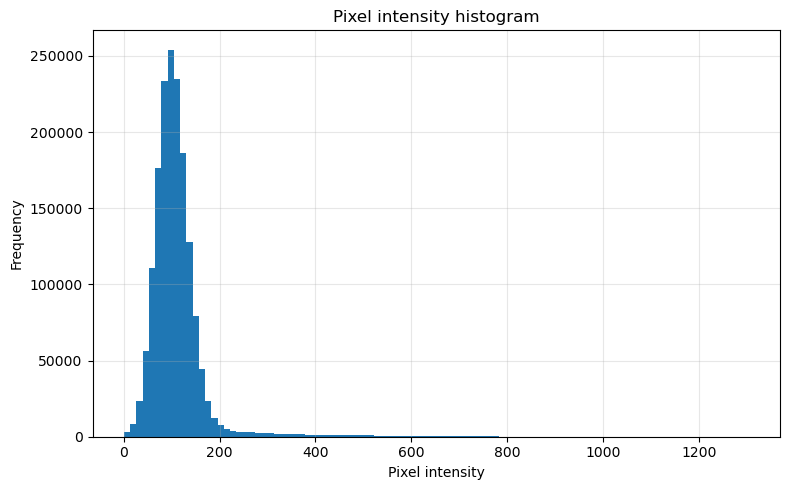

In [29]:
sim.histogram(bins=100)

In [30]:
max = np.max(frames)
min = max - 0.5*max
print(min)
print(max)

651.9808959960938
1303.9618


In [31]:
# tuned version for the experiment
def track(
    frames,
    trajectories_GT,
    detection_threshold=500,
    max_distance=10,
    min_length=5,
    r_squared_threshold=0.5,
    algo_peak2peak="hungarian",
    algo_traj2traj="hungarian",
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
):

    detected_peaks = detect_peaks(frames, threshold_abs=detection_threshold, min_distance=1)

    # localized_peaks = localize_peaks_with_gaussian_fitting(
    #     frames,
    #     detected_peaks,
    #     r_squared_threshold=r_squared_threshold,
    #     verbose=verbose_loc,
    #     visualization=visualization_loc,
    #     visualization_peak_idx=1,
    # )

    # trajectories_localization, cost_peak2peak = track_peaks_to_trajectories(
    #     peaks=localized_peaks,
    #     max_distance=max_distance,
    #     min_length=min_length,
    #     algorithm=algo_peak2peak,
    #     cost_function=cost_function,
    # )

    # (
    #     trajectories_localization,
    #     cost_traj2traj,
    #     assignment_localization,
    # ) = assign_trajectories(
    #     trajectories_localization,
    #     trajectories_GT,
    #     algorithm=algo_traj2traj,
    #     verbose=verbose_assignment,
    # )

    return detected_peaks

In [32]:
det_thresh_range = np.linspace(max-0.75*max, max, 75)
k_values = np.linspace(-0.75, 0.0, 75)
# ground truth number of fits is nparticles * nframes, since we have nparticles per frame and nframes total frames
tot_particles = simulation_config["nparticles"] * simulation_config["nframes"]
detected_peaks_range = []

for det_tr in det_thresh_range:
   print(f"Detection threshold: {det_tr:.2f}")
   detected_peaks = track(frames, trajectories_GT, detection_threshold=det_tr, verbose_loc=False)
   total_num_peaks = np.sum([len(peaks) for peaks in detected_peaks])
   print("Number of detected peaks:", total_num_peaks)
   detected_peaks_range.append(total_num_peaks)


Detection threshold: 325.99
Number of detected peaks: 2092
Detection threshold: 339.21
Number of detected peaks: 2067
Detection threshold: 352.42
Number of detected peaks: 2044
Detection threshold: 365.64
Number of detected peaks: 2029
Detection threshold: 378.85
Number of detected peaks: 2005
Detection threshold: 392.07
Number of detected peaks: 1979
Detection threshold: 405.29
Number of detected peaks: 1947
Detection threshold: 418.50
Number of detected peaks: 1919
Detection threshold: 431.72
Number of detected peaks: 1884
Detection threshold: 444.93
Number of detected peaks: 1848
Detection threshold: 458.15
Number of detected peaks: 1806
Detection threshold: 471.36
Number of detected peaks: 1762
Detection threshold: 484.58
Number of detected peaks: 1734
Detection threshold: 497.80
Number of detected peaks: 1701
Detection threshold: 511.01
Number of detected peaks: 1662
Detection threshold: 524.23
Number of detected peaks: 1625
Detection threshold: 537.44
Number of detected peaks: 15

In [33]:
print(len(detected_peaks_range))
print(len(det_thresh_range))

75
75


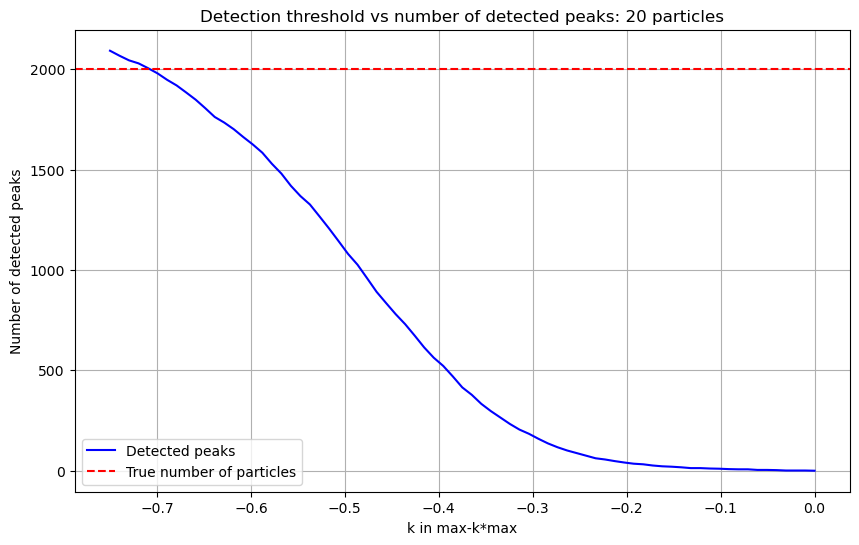

In [34]:
# find indices where detection matches ground truth
good_idx = np.where(np.array(detected_peaks_range) == tot_particles)[0]

# group contiguous regions
good_regions = []
if len(good_idx) > 0:
    start = good_idx[0]
    for i in range(1, len(good_idx)):
        if good_idx[i] != good_idx[i-1] + 1:
            good_regions.append((start, good_idx[i-1]))
            start = good_idx[i]
    good_regions.append((start, good_idx[-1]))

plt.figure(figsize=(10, 6))
plt.plot(k_values, detected_peaks_range, label="Detected peaks", color="blue")
plt.axhline(y=tot_particles, color="red", linestyle="--", label="True number of particles")

# highlight regions + add center markers
for start, end in good_regions:
    k_left = k_values[start]
    k_right = k_values[end]
    k_center = 0.5 * (k_left + k_right)

    # shaded region
    plt.axvspan(k_left, k_right, color="green", alpha=0.2)

    # vertical line at center
    plt.axvline(k_center, color="green", linestyle="-", alpha=0.8)

    # annotate boundaries and center
    plt.text(k_left, tot_particles * 1.02, f"{k_left:.2f}", ha="center", color="green")
    plt.text(k_center, tot_particles * 1.05, f"{k_center:.2f}", ha="center", color="green", fontweight="bold")
    plt.text(k_right, tot_particles * 1.02, f"{k_right:.2f}", ha="center", color="green")

plt.xlabel("k in max-k*max")
plt.ylabel("Number of detected peaks")
plt.title(f"Detection threshold vs number of detected peaks: {simulation_config['nparticles']} particles")
plt.legend()
plt.grid()
plt.show()


## Repeat experiment to identify right value

In [35]:
# k_centers = []
# nparticles_range = np.linspace(5,45,45, dtype=int)
# nframes=1

In [36]:
# for nparticles in nparticles_range:
#     trajectories = simulate_brownian_motion(
#     nparticles=nparticles,
#     nframes=nframes,
#     nposframe=nposframe,
#     D_list=D_list,
#     dt=1.0,
#     anisotropy_ratio_range=(1.0, 1.0),
#     theta_range=(np.deg2rad(0), np.deg2rad(0)),
#     frame_size=(128, 128),
#     intensity_mean=intensity_mean,
#     intensity_std=intensity_std
#     )

#     video= trajectories_to_global_video(
#     trajectories, # still at subframe resolution
#     nframes=nframes,
#     nPosPerFrame=nposframe,
#     image_props=image_props
#     )
    
#     trajectories_GT = create_GT_trajectories(trajectories, nposframe)
#     frames = video.astype(np.float32)

#     det_thresh_range = np.linspace(intensity_mean - 1.2*intensity_std,
#                                intensity_mean + 1.2*intensity_std,
#                                100)
#     k_values = (det_thresh_range - intensity_mean) / intensity_std
#     # ground truth number of fits is nparticles * nframes, since we have nparticles per frame and nframes total frames
#     tot_particles = nparticles * nframes
#     detected_peaks_range = []

#     for det_tr in det_thresh_range:
#         print(f"Detection threshold: {det_tr:.2f}")
#         detected_peaks = track(frames, trajectories_GT, detection_threshold=det_tr, verbose_loc=False)
#         total_num_peaks = np.sum([len(peaks) for peaks in detected_peaks])
#         print("Number of detected peaks:", total_num_peaks)
#         detected_peaks_range.append(total_num_peaks)

#     # find indices where detection matches ground truth
#     good_idx = np.where(np.array(detected_peaks_range) == tot_particles)[0]

#     middle_k = None
#     if len(good_idx) > 0:
#         mid_index = good_idx[len(good_idx) // 2]   # integer middle
#         middle_k = k_values[mid_index]

#     k_centers.append(middle_k)

In [37]:
# # plot k_centers vs nparticles
# plt.figure(figsize=(10, 6))
# plt.scatter(nparticles_range, k_centers, s=60)
# plt.xlabel("Number of particles")
# plt.ylabel("Center k-value")
# plt.title("Center k-value vs number of particles")
# plt.grid()
# plt.show()

=> for now, arbitrarily selected -0.7.  
=> that is, optimal detection threshold is at $\bar{I}-0.7 \sigma_{I}$   
=> For $\bar{I}=700$ and $\sigma_{I}=300$, the optimal detection thresold is $k=700-0.7$ $\times 300 = 490$.

----

## Visual evaluation

In [ ]:
# set k
k = 0.7

def detectFromFrames(frames, k, verbose=False):
    # get image min and max
    max = np.max(frames)
    min = np.min(frames)

    # detect peaks with chosen threshold
    detection_threshold = max - k * (max - min)
    if verbose:
        print(f"Chosen detection threshold: {detection_threshold:.2f}")
    detected_peaks = track(frames, trajectories_GT, detection_threshold=detection_threshold, verbose_loc=False)
    return detected_peaks

def visualizePeaksOnVideo(video, detected_peaks):
    # convert grayscale video to uint8 first
    video_uint8 = (255 * (video - video.min()) / (video.max() - video.min())).astype(np.uint8)

    # convert to RGB
    video_vis = np.stack([video_uint8, video_uint8, video_uint8], axis=-1).copy()

    # draw red crosses
    for frame_idx, peaks in enumerate(detected_peaks):
        for (y, x) in peaks:
            # vertical line
            video_vis[frame_idx, y-1:y+2, x, 0] = 255   # R
            video_vis[frame_idx, y-1:y+2, x, 1] = 0     # G
            video_vis[frame_idx, y-1:y+2, x, 2] = 0     # B

            # horizontal line
            video_vis[frame_idx, y, x-1:x+2, 0] = 255
            video_vis[frame_idx, y, x-1:x+2, 1] = 0
            video_vis[frame_idx, y, x-1:x+2, 2] = 0

    # animate
    animate_video(video_vis, interval=100)

In [39]:
# math metric to compare: show number of detections per frame for the given threshold, with a horuizontal line for the true number of particles
def plotNumDetectionsPerFrame(detections_list, nparticles, k_range):
    plt.figure(figsize=(10, 6))
    for i, detections in enumerate(detections_list):
        detections_per_frame = [len(peaks) for peaks in detections]
    
        plt.plot(detections_per_frame, label=f"k={k_range[i]:.2f}")

    plt.axhline(y=nparticles, color="red", linestyle="--", label="True number of particles")
    plt.xlabel("Frame index")
    plt.ylabel("Number of detected peaks")
    plt.title(f"Number of detected peaks per frame with varying k")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# identified good range sits between 0.6 and 0.8: try with this refined range and superimpose curves

k_range = np.linspace(0.65, 0.75, 10)
detections_per_k = []+

for k in k_range:
    detection_threshold = max - k * (max - min)
    detected_peaks = detectFromFrames(frames, k)
    detections_per_k.append(detected_peaks)


Chosen detection threshold: 456.39
Chosen detection threshold: 441.90
Chosen detection threshold: 427.41
Chosen detection threshold: 412.92
Chosen detection threshold: 398.43
Chosen detection threshold: 383.94
Chosen detection threshold: 369.46
Chosen detection threshold: 354.97
Chosen detection threshold: 340.48
Chosen detection threshold: 325.99


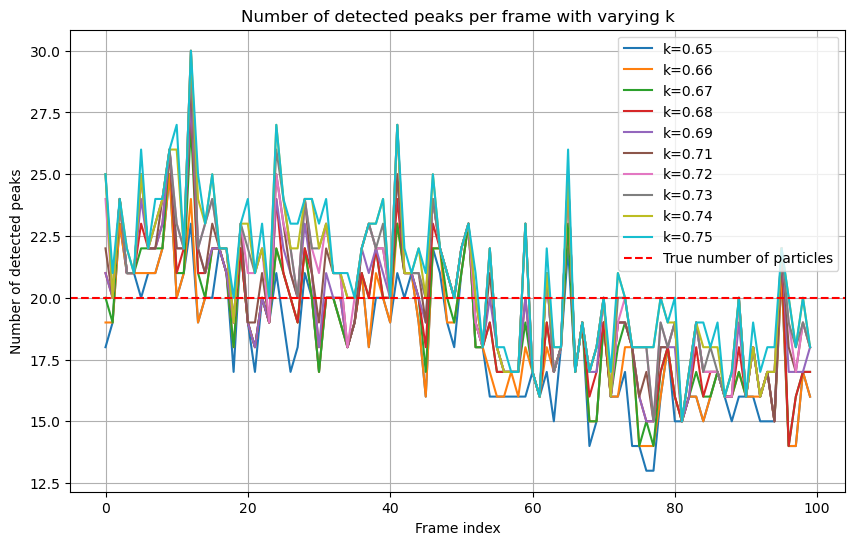

In [52]:
plotNumDetectionsPerFrame(detections_per_k, nparticles, k_range) 

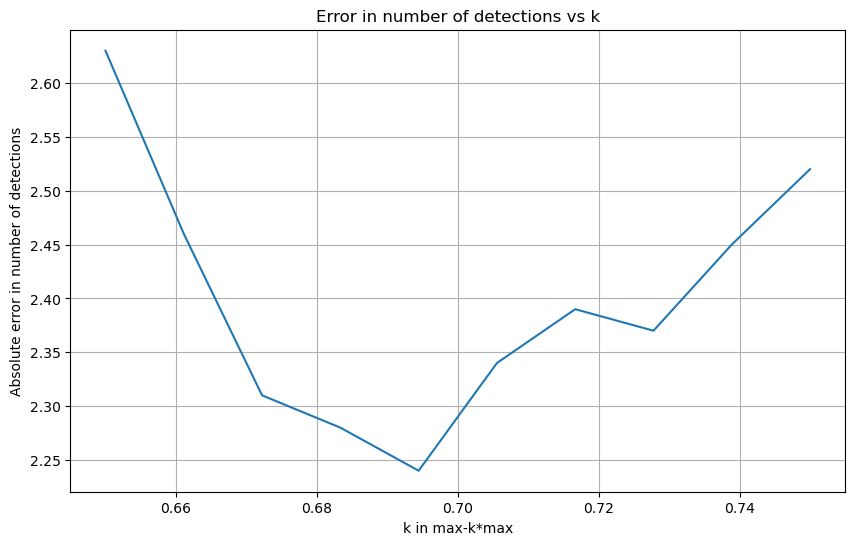

In [53]:
# calculate best k with least squares between number of detections per frame and true number of particles, for each k, and plot the error as a function of k to find the minimum
errors = []
for detection in detections_per_k:
    detections_per_frame = [len(peaks) for peaks in detection]
    error = np.abs(np.array(detections_per_frame) - nparticles)
    errors.append(np.mean(error))
plt.figure(figsize=(10, 6))
plt.plot(k_range, errors)
plt.xlabel("k in max-k*max")
plt.ylabel("Absolute error in number of detections")
plt.title("Error in number of detections vs k")
plt.grid()
plt.show()

In [54]:
print("Best k:", k_range[np.argmin(errors)])

Best k: 0.6944444444444444


Chosen detection threshold: 423.36
Chosen detection threshold: 409.92
Chosen detection threshold: 396.48
Chosen detection threshold: 383.04
Chosen detection threshold: 369.60
Chosen detection threshold: 356.16
Chosen detection threshold: 342.72
Chosen detection threshold: 329.28
Chosen detection threshold: 315.84
Chosen detection threshold: 302.40
Chosen detection threshold: 391.04
Chosen detection threshold: 378.63
Chosen detection threshold: 366.22
Chosen detection threshold: 353.80
Chosen detection threshold: 341.39
Chosen detection threshold: 328.97
Chosen detection threshold: 316.56
Chosen detection threshold: 304.15
Chosen detection threshold: 291.73
Chosen detection threshold: 279.32
Chosen detection threshold: 396.57
Chosen detection threshold: 383.98
Chosen detection threshold: 371.39
Chosen detection threshold: 358.80
Chosen detection threshold: 346.21
Chosen detection threshold: 333.62
Chosen detection threshold: 321.03
Chosen detection threshold: 308.44
Chosen detection thr

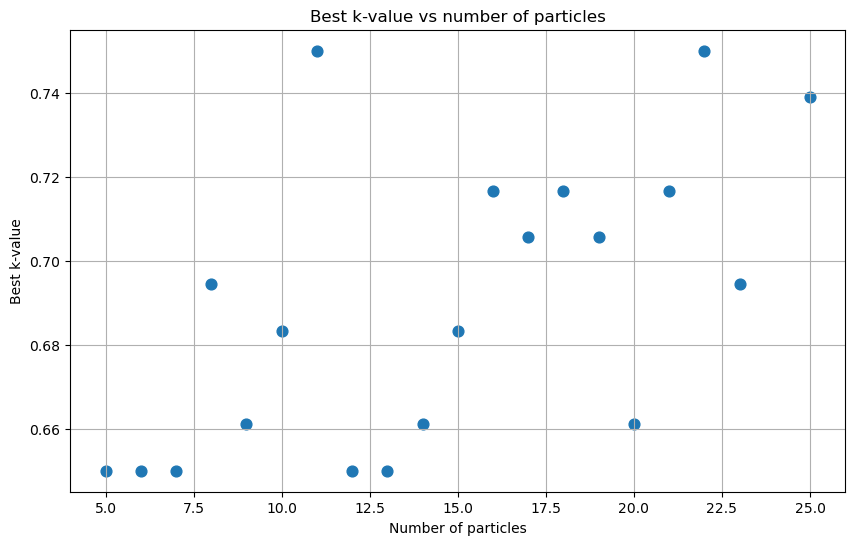

In [57]:
# repeat full pipeline with varying number of particles for consistency check
nframes = 50

best_k_list = []

nparticles_range = np.linspace(5,25,20, dtype=int)

for nparticles in nparticles_range:
    trajectories = simulate_brownian_motion(
    nparticles=nparticles,
    nframes=nframes,
    nposframe=simulation_config["nposframe"],
    D_list=simulation_config["D_list"],
    dt=simulation_config["dt"],
    anisotropy_ratio_range=simulation_config["anisotropy_ratio_range"],
    theta_range=simulation_config["theta_range"],
    frame_size=simulation_config["frame_size"],
    intensity_mean=simulation_config["intensity_mean"],
    intensity_std=simulation_config["intensity_std"]
    )

    video= trajectories_to_global_video(
    trajectories, # still at subframe resolution
    nframes=simulation_config["nframes"],
    nPosPerFrame=simulation_config["nposframe"],
    image_props=image_config
    )
    
    trajectories_GT = create_GT_trajectories(trajectories, simulation_config["nposframe"])
    frames = video.astype(np.float32)

    k_range = np.linspace(0.65, 0.75, 10)
    
    detections_per_k = []

    for k in k_range:
        detection_threshold = max - k * (max - min)
        detected_peaks = detectFromFrames(frames, k)
        detections_per_k.append(detected_peaks)
    
    errors = []

    for detection in detections_per_k:
        detections_per_frame = [len(peaks) for peaks in detection]
        error = np.abs(np.array(detections_per_frame) - nparticles)
        errors.append(np.mean(error))

    best_k = k_range[np.argmin(errors)]
    best_k_list.append(best_k)

plt.figure(figsize=(10, 6))
plt.scatter(nparticles_range, best_k_list, s=60)
plt.xlabel("Number of particles")
plt.ylabel("Best k-value")
plt.title("Best k-value vs number of particles")
plt.grid()
plt.show()

In [58]:
print(np.mean(best_k_list))

0.6894444444444445


-> let's choose 0.69...